In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### **Ejercicio N°1**

El dataset `winequality-red.csv` contiene un conjunto de variables relacionadas con propiedades fisicoquímicas que fueron determinadas sobre una serie de vinos de una misma variedad, así como un puntaje asignado en cada caso por un panel de enólogos en sesiones de cata. Importe el dataset al entorno de trabajo y realice cualquier tipo de limpieza y adecuación del mismo que considere necesaria para su posterior análisis.

1. Clasifique las variables del dataset en cualitativas, cuantitativas discretas y cuantitativas continuas.

2. El 25% de los vinos del dataset tiene un contenido de alcohol superior a… ¿qué valor?

In [2]:
vinos=pd.read_csv('./datasets/winequality-red.csv')
vinos.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
vinos['alcohol'].value_counts()

alcohol
9.500000     139
9.400000     103
9.800000      78
9.200000      72
10.000000     67
            ... 
9.950000       1
9.233333       1
9.250000       1
9.050000       1
10.750000      1
Name: count, Length: 65, dtype: int64

In [4]:
porc_alc=vinos['alcohol'].quantile(q=0.75)
print(f'el 25% de los vinos supera el {porc_alc} de graduacion alcoholica')

el 25% de los vinos supera el 11.1 de graduacion alcoholica


3. Realice una tabla en la que se presenten, para las variables densidad y pH, **únicamente** las siguientes medidas descriptivas: media, mediana, desvío estándar y rango intercuartil. A continuación, responda a las siguientes preguntas **sin realizar ningún gráfico:**

- ¿Cómo describiría ambas distribuciones en relación a sus características de simetría?
- ¿Cuál de los dos conjuntos de observaciones (densidad o pH) presenta mayor variabilidad?

In [5]:
dens_ph_media=vinos[['density', 'pH']].mean()
dens_ph_mediana=vinos[['density', 'pH']].median()
dens_ph_desv_estandar=vinos[['density', 'pH']].std()
dens_ph_rango_interq=dens_rango_interq=vinos[['density','pH']].quantile(q=0.75)-vinos[['density','pH']].quantile(q=0.25)

ph_rango_interq=vinos['pH'].quantile(q=0.75)-vinos['pH'].quantile(q=0.25)

df1 = pd.DataFrame({'Media':dens_ph_media,
                    'Median':dens_ph_mediana,
                    'Desv. estandar' : dens_ph_desv_estandar,
                    'Rango Intercuartil' : dens_ph_rango_interq} )
df1

,Media,Median,Desv. estandar,Rango Intercuartil
density,0.996747,0.99675,0.001887,0.002235
pH,3.311113,3.31000,0.154386,0.190000


4. Represente la distribución de las observaciones de la variable contenido de alcohol (alcohol) a través de un boxplot. *Sugerencia*: utilice la función `sns.boxplot()` de la librería  `seaborn`. Basándose en el gráfico, ¿cuál de las siguientes medidas de posición o centralidad (media aritmética/mediana) le parece más adecuada para describir a esta variable?

<Axes: xlabel='alcohol'>

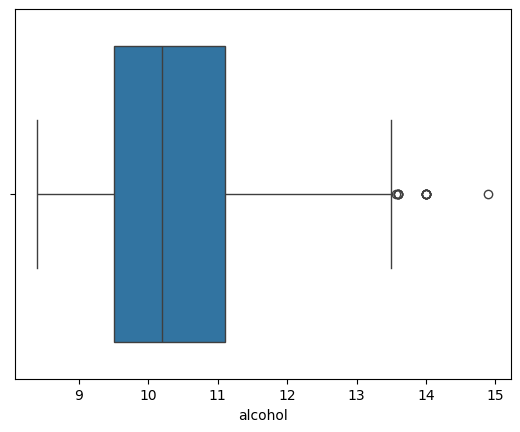

In [6]:
sns.boxplot(data=vinos, x='alcohol')

5. Realice una tabla de frecuencias para resumir la distribución de los vinos del dataset en función del puntaje asignado según su calidad (quality).

- ¿Cuál de los puntajes fue recibido por una mayor cantidad de vinos?
- ¿Qué porcentaje de los vinos de la muestra recibieron la calificación más baja?

In [10]:
frec_abs=vinos['quality'].value_counts().sort_index()

frec_relat=vinos['quality'].value_counts(normalize=True).sort_index().round(2)

tabla_frecuencias=pd.DataFrame={'Frecuencia Absoluta':frec_abs,
              'Porcentaje': frec_relat*100}
tabla_frecuencias

{'Frecuencia Absoluta': quality
 3     10
 4     53
 5    681
 6    638
 7    199
 8     18
 Name: count, dtype: int64,
 'Porcentaje': quality
 3     1.0
 4     3.0
 5    43.0
 6    40.0
 7    12.0
 8     1.0
 Name: proportion, dtype: float64}

In [8]:
frec_abs

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

In [9]:
frec_relat

quality
3    0.01
4    0.03
5    0.43
6    0.40
7    0.12
8    0.01
Name: proportion, dtype: float64